# ID3 Decision Tree Analysis
This notebook implements the ID3 (Iterative Dichotomiser 3) algorithm to classify data based on Information Gain and Entropy.

In [1]:
from collections import Counter, defaultdict
import math
from functools import partial
import matplotlib.pyplot as plt

def entropy(probabilities):
    return sum(-p * math.log2(p) for p in probabilities if p > 0)


def class_probabilities(labels):
    if not labels:
        return []
    total_count = len(labels)
    return [count / total_count for count in Counter(labels).values()]


def data_entropy(labeled_data):
    if not labeled_data:
        return 0.0
    labels = [label for _, label in labeled_data]
    return entropy(class_probabilities(labels))


def partition_entropy(subsets):
    total_count = sum(len(subset) for subset in subsets)
    return sum(data_entropy(subset) * len(subset) / total_count
               for subset in subsets)


def partition_by(dataset, attribute):
    groups = defaultdict(list)
    for entry in dataset:
        key = entry[0].get(attribute)
        groups[key].append(entry)
    return groups


def partition_entropy_by(dataset, attribute):
    partitions = partition_by(dataset, attribute)
    return partition_entropy(partitions.values())


def classify(tree, data_point):
    if not isinstance(tree, tuple):
        return tree
    attribute, subtree_dict = tree
    attribute_value = data_point.get(attribute)
    if attribute_value not in subtree_dict:
        attribute_value = None
    subtree = subtree_dict[attribute_value]
    return classify(subtree, data_point)


def build_tree_id3(dataset, split_candidates=None):
    if split_candidates is None:
        split_candidates = dataset[0][0].keys()
    labels = [label for _, label in dataset]
    num_trues = len([l for l in labels if l is True])
    num_falses = len(labels) - num_trues

    if num_trues == 0: return False
    if num_falses == 0: return True

    if not split_candidates:
        return num_trues >= num_falses

    best_attribute = min(split_candidates,
                         key=partial(partition_entropy_by, dataset))
    partitions = partition_by(dataset, best_attribute)
    new_candidates = [a for a in split_candidates if a != best_attribute]
    subtrees = {
        attribute_value: build_tree_id3(subset, new_candidates)
        for attribute_value, subset in partitions.items()
    }
    subtrees[None] = num_trues >= num_falses

    return best_attribute, subtrees

In [2]:
dataset = [
    ({'level':'Senior', 'lang':'Java', 'tweets':'no', 'phd':'no'}, False),
    ({'level':'Senior', 'lang':'Java', 'tweets':'no', 'phd':'yes'}, False),
    ({'level':'Mid', 'lang':'Python', 'tweets':'no', 'phd':'no'}, True),
    ({'level':'Junior', 'lang':'Python', 'tweets':'no', 'phd':'no'}, True),
    ({'level':'Junior', 'lang':'R', 'tweets':'yes', 'phd':'no'}, True),
    ({'level':'Junior', 'lang':'R', 'tweets':'yes', 'phd':'yes'}, False),
    ({'level':'Mid', 'lang':'R', 'tweets':'yes', 'phd':'yes'}, True),
    ({'level':'Senior', 'lang':'Python', 'tweets':'no', 'phd':'no'}, False),
    ({'level':'Senior', 'lang':'R', 'tweets':'yes', 'phd':'no'}, True),
    ({'level':'Junior', 'lang':'Python', 'tweets':'yes', 'phd':'no'}, True),
    ({'level':'Senior', 'lang':'Python', 'tweets':'yes', 'phd':'yes'}, True),
    ({'level':'Mid', 'lang':'Python', 'tweets':'no', 'phd':'yes'}, True),
    ({'level':'Mid', 'lang':'Java', 'tweets':'yes', 'phd':'no'}, True),
    ({'level':'Junior', 'lang':'Python', 'tweets':'no', 'phd':'yes'}, False)
]

In [3]:
def plot_simple_tree(tree):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.axis('off')

    def draw_node(node, x, y, dx):
        if not isinstance(node, tuple):
            color = '#2ecc71' if node is True else '#e74c3c'
            ax.text(x, y, f"{node}", bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.6),
                    ha='center', va='center', fontsize=12, fontweight='bold')
            return

        attribute, subtrees = node

        ax.text(x, y, attribute, bbox=dict(boxstyle='square,pad=0.5', facecolor='#34495e', alpha=0.8),
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')

        valid_branches = {k: v for k, v in subtrees.items() if k is not None}
        num_branches = len(valid_branches)

        start_x = x - (dx * (num_branches - 1) / 2)
        for i, (value, subtree) in enumerate(valid_branches.items()):
            child_x = start_x + (i * dx)
            child_y = y - 1.0

            ax.plot([x, child_x], [y - 0.15, child_y + 0.15], '-', color='#7f8c8d', lw=1.5)
            ax.text((x + child_x)/2, (y + child_y)/2, str(value), ha='center', va='center',
                    fontsize=10, backgroundcolor='#7f8c8d')

            draw_node(subtree, child_x, child_y, dx * 0.4)

    draw_node(tree, x=0, y=0, dx=2.0)
    plt.show()

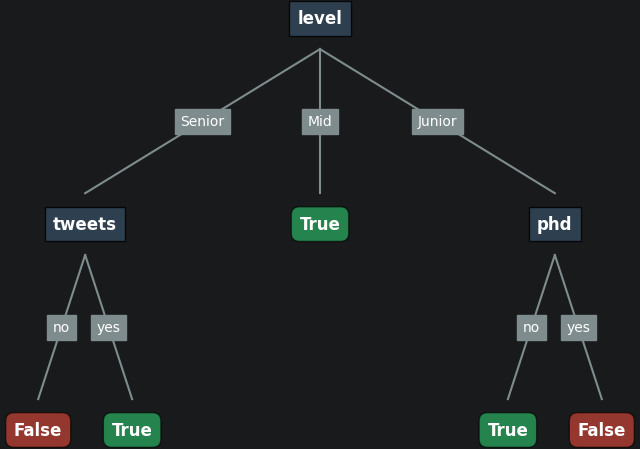

In [8]:
tree = build_tree_id3(dataset)
plot_simple_tree(tree)

In [9]:
individual = {'level':'Junior', 'lang':'Python', 'tweets':'no', 'phd':'yes'}
classify(tree, individual)

False